[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brianjalaian/CAP6606_ML_ISR/blob/main/modules/11_pytorch/ch13_part1-UWFLecture.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/brianjalaian/CAP6606_ML_ISR/blob/main/modules/11_pytorch/ch13_part1-UWFLecture.ipynb)


# Chapter 13: Going Deeper -- the Mechanics of PyTorch (Part 1/2)

---

## Prework
### Import essentials

In [2]:
from IPython.display import Image
%matplotlib inline

### Check package version (optional)

Add folder to path in order to load from the `check_packages.py` script.

In [3]:
import sys
sys.path.insert(0, '..')

Check recommended package versions.

In [4]:
from python_environment_check import check_packages


d = {
    'numpy': '1.21.2',
    'matplotlib': '3.4.3',
    'torch': '1.8',
    'mlxtend': '0.19.0'
}
check_packages(d)

[OK] Your Python version is 3.8.0 (tags/v3.8.0:fa919fd, Oct 14 2019, 19:37:50) [MSC v.1916 64 bit (AMD64)]
[FAIL]: mlxtend is not installed and/or cannot be imported.
[OK] numpy 1.22.3
[OK] matplotlib 3.5.1
[OK] torch 2.1.1+cpu


### Watermark (optional)

Optional watermark extension is a small IPython notebook plugin that I developed to make the code reproducible.

You can install `watermark` Jupyter extension via

    conda install watermark -c conda-forge  

or  

    pip install watermark   

For more information, please see: https://github.com/rasbt/watermark.

In [5]:
%load_ext watermark
%watermark -a "Sebastian Raschka, Johnny Yu" -u -d -v -p numpy,pandas,matplotlib,scipy,sklearn

Author: Sebastian Raschka, Johnny Yu

Last updated: 2023-12-18

Python implementation: CPython
Python version       : 3.8.0
IPython version      : 8.12.2

numpy     : 1.22.3
pandas    : 2.0.3
matplotlib: 3.5.1
scipy     : 1.8.0
sklearn   : 1.3.2



---

## Table of Contents

- [13.1.The key features of PyTorch](#13.1.The-key-features-of-PyTorch)
- [13.2.PyTorch's computation graphs](#13.2.PyTorchs-computation-graphs)
  - [13.2.1.Understanding computation graphs](#13.2.1.Understanding-computation-graphs)
  - [13.2.2.Creating a graph in PyTorch](#13.2.2.Creating-a-graph-in-PyTorch)
- [13.3.PyTorch tensor objects for storing and updating model parameters](#13.3.PyTorch-tensor-objects-for-storing-and-updating-model-parameters)
- [13.4.Computing gradients via automatic differentiation](#13.4.Computing-gradients-via-automatic-differentiation)
  - [13.4.1.Computing the gradients of the loss with respect to trainable variables](#13.4.1.Computing-the-gradients-of-the-loss-with-respect-to-trainable-variables)
  - [13.4.2.Understanding automatic differentiation](#13.4.2.Understanding-automatic-differentiation)
  - [13.4.3.Adversarial examples](#13.4.3.Adversarial-examples)
- [13.5.Simplifying implementations of common architectures via the torch.nn module](#13.5.Simplifying-implementations-of-common-architectures-via-the-torch.nn-module)
  - [13.5.1.Implementing models based on nn.Sequential](#13.5.1.Implementing-models-based-on-nn-Sequential)
  - [13.5.2.Choosing a loss function](#13.5.2.Choosing-a-loss-function)
  - [13.5.3.Solving an XOR classification problem](#13.5.3.Solving-an-XOR-classification-problem)
  - [13.5.4.Making model building more flexible with nn.Module](#13.5.4.Making-model-building-more-flexible-with-nn.Module)
  - [13.5.5.Writing custom layers in PyTorch](#13.5.5.Writing-custom-layers-in-PyTorch)

---

## 13.1.The key features of PyTorch
No code provided.

---

## 13.2.PyTorch's computation graphs

### 13.2.1.Understanding computation graphs
PyTorch relies on building a computation graph at its core, and it uses this computation graph to derive relationships between tensors from the input all the way to the output. PyTorch builds this computation graph and uses it to compute the gradients accordingly. 

Let's say that we have rank 0 (scalar) tensors $a, b$, and $c$ and we want to evaluate $z=2 \times(a-b)+c$.


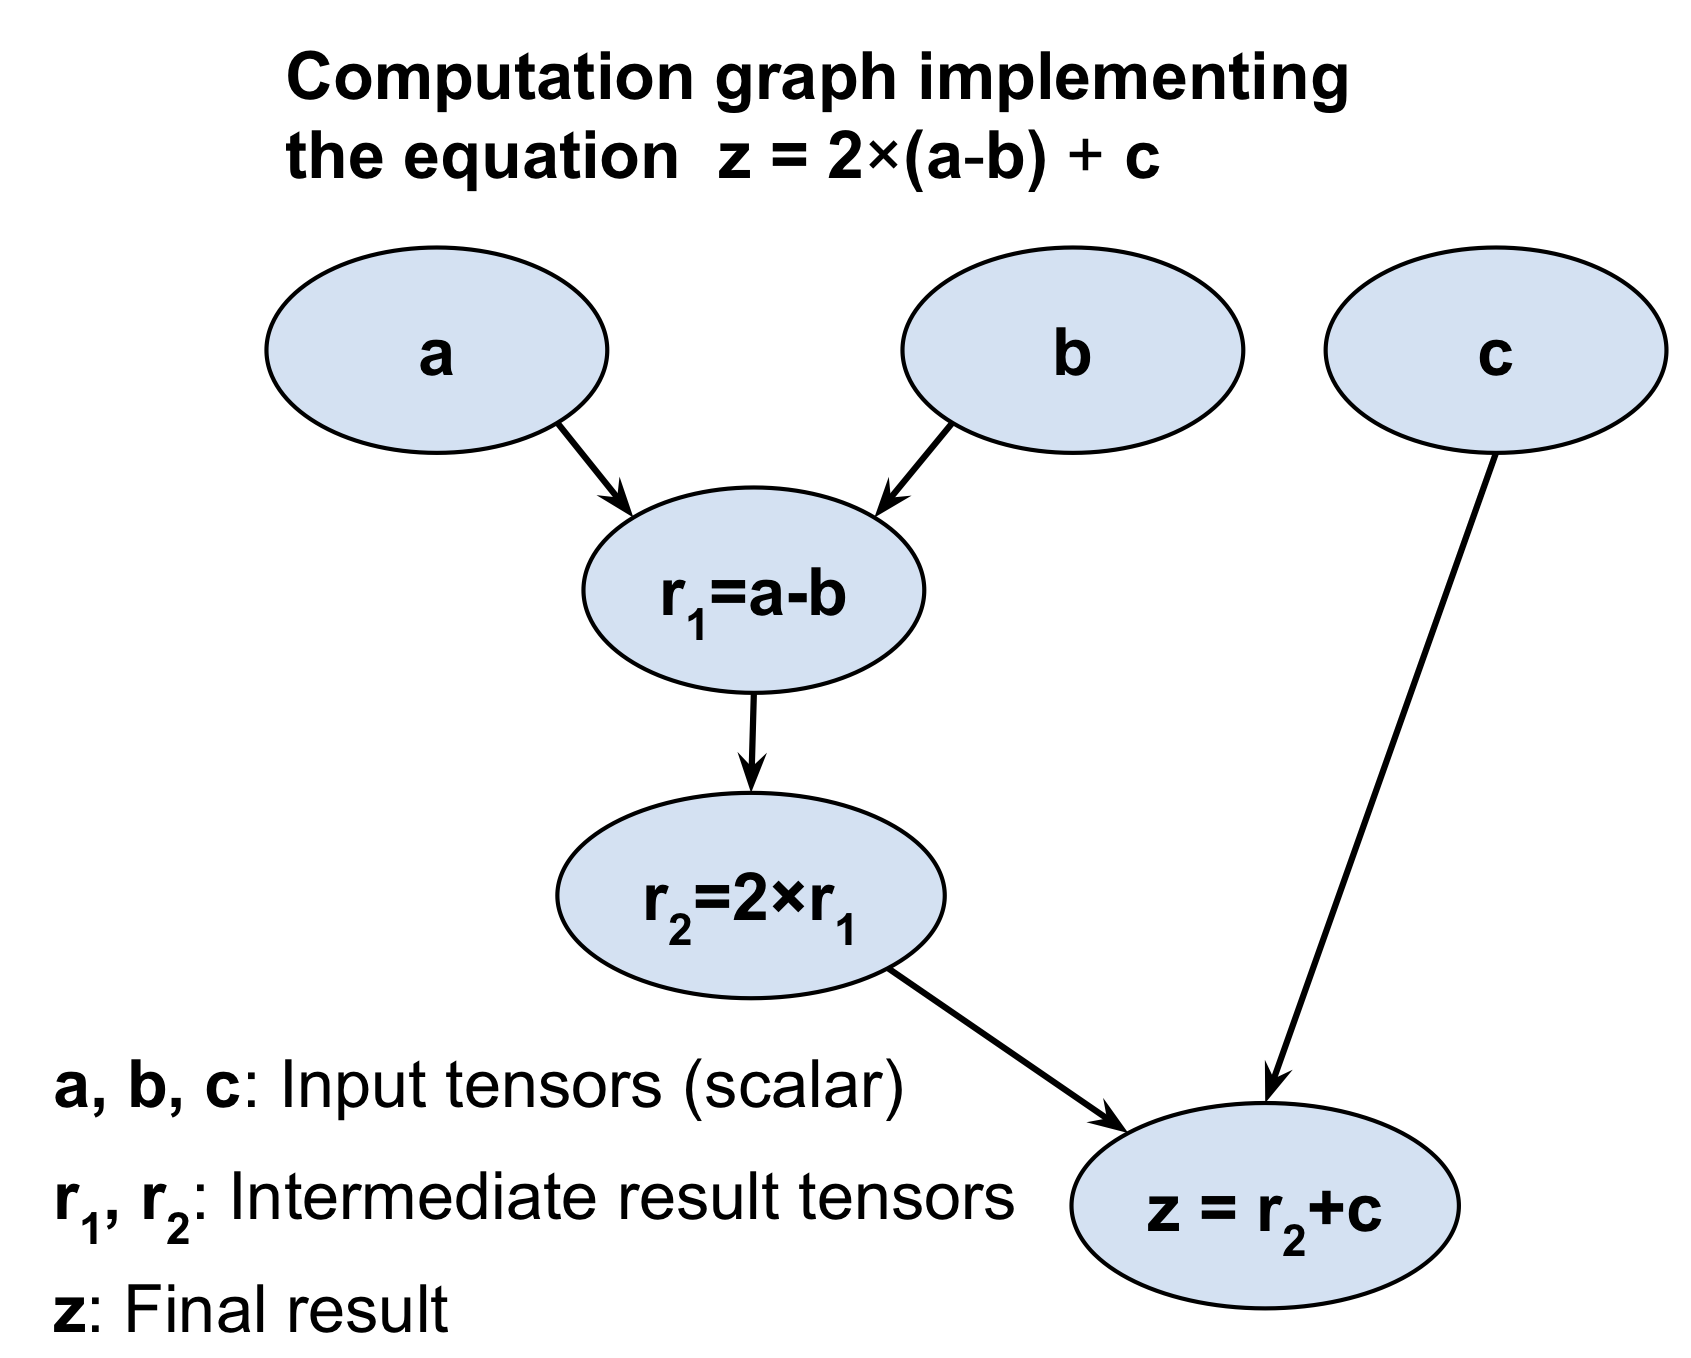

In [6]:
Image(filename='figures/13_01.png', width=400)

### 13.2.2.Creating a graph in PyTorch
Let's look at a simple example that illustrates how to create a graph in PyTorch for evaluating $z=2 \times(a-b)+c$, as shown in the previous figure. The variables $a, b$, and $c$ are scalars (single numbers), and we define these as PyTorch tensors. To create the graph, we can simply define a regular Python function with `a`, `b`, and `c` as its input arguments.

In [7]:
import torch


def compute_z(a, b, c):
    r1 = torch.sub(a, b)
    r2 = torch.mul(r1, 2)
    z = torch.add(r2, c)
    return z

Now, to carry out the computation, we can simply call this function with tensor objects as function arguments. Note that PyTorch functions such as `add`, `sub` (or `subtract`), and `mul` (or `multiply`) also allow us to provide inputs of higher ranks in the form of a PyTorch tensor object. In the following code example, we provide scalar inputs (rank-0), as well as rank-1 and rank 2 inputs.

In [8]:

print('Scalar Inputs:', compute_z(torch.tensor(1), torch.tensor(2), torch.tensor(3)))
print('Rank 1 Inputs:', compute_z(torch.tensor([1]), torch.tensor([2]), torch.tensor([3])))
print('Rank 2 Inputs:', compute_z(torch.tensor([[1]]), torch.tensor([[2]]), torch.tensor([[3]])))

Scalar Inputs: tensor(1)
Rank 1 Inputs: tensor([1])
Rank 2 Inputs: tensor([[1]])


---

## 13.3.PyTorch Tensor objects for storing and updating model parameters
In PyTorch, a special tensor object for which gradients need to be computed allows us to store and update the parameters of our models during training. Such a tensor can be created by just assigning `requires_grad` to `True` on user-specified initial values.

In [9]:
a = torch.tensor(3.14, requires_grad=True)
b = torch.tensor([1.0, 2.0, 3.0], requires_grad=True) 
print(a)
print(b)

tensor(3.1400, requires_grad=True)
tensor([1., 2., 3.], requires_grad=True)


Notice that `requires_grad` is set to `False` by default. This value can be efficiently set to `True` by running `requires_grad_()`.

In [10]:
a.requires_grad

True

In [11]:
w = torch.tensor([1.0, 2.0, 3.0])

print(w.requires_grad)

False


In [12]:
w.requires_grad_()

print(w.requires_grad)

True


**Xavier initialization**

You will recall that for NN models, initializing model parameters with random weights is necessary to break the symmetry during backpropagation - otherwise, a multilayer NN would be no more useful than a single-layer NN like logistic regression. When creating a PyTorch tensor, we can also use a random initialization scheme. PyTorch can generate random numbers based on a variety of probability distributions (see https://pytorch.org/docs/stable/torch.html\#random-sampling). In the following example, we will take a look at some standard initialization methods that are also available in the `torch.nn.init` module (see https://pytorch.org/docs/stable/nn.init.html).

So, let's look at how we can create a tensor with Xavier initialization, which is a classic random initialization scheme that was proposed by Xavier Glorot and Yoshua Bengio. For this, we first create an empty tensor and an operator called `init` as an object of class `GlorotNormal`. Then, we fill this tensor with values according to the Xavier initialization by calling the `xavier_normal_()` method. In the following example, we initialize a tensor of shape $2 \times 3$.

In [13]:
import torch.nn as nn


torch.manual_seed(1)
w = torch.empty(2, 3)
nn.init.xavier_normal_(w)
print(w)
 

tensor([[ 0.4183,  0.1688,  0.0390],
        [ 0.3930, -0.2858, -0.1051]])


In [14]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.w1 = torch.empty(2, 3, requires_grad=True)
        nn.init.xavier_normal_(self.w1)
        self.w2 = torch.empty(1, 2, requires_grad=True)
        nn.init.xavier_normal_(self.w2)


---

## 13.4.Computing gradients via automatic differentiation
As you already know, optimizing NNs requires computing the gradients of the loss with respect to the NN weights. This is required for optimization algorithms such as *stochastic gradient descent (SGD)*. In addition, gradients have other applications, such as diagnosing the network to find out why an NN model is making a particular prediction for a test example. Therefore, in this section, we will cover how to compute gradients of a computation with respect to its input variables.

### 13.4.1.Computing the gradients of the loss with respect to trainable variables
PyTorch supports *automatic differentiation*, which can be thought of as an implementation of the *chain rule* for computing gradients of nested functions. Note that for the sake of simplicity, we will use the term *gradient* to refer to both partial derivatives and gradients.

Let's work with a simple example where we will compute $z=w x+b$ and define as follows:
- *feature* = $x$
- *target* = $y$
- *prediction* = $z$
- *the squared loss* = $(y-z)^2$ 

In the more general case, where we may have multiple predictions and targets, we compute the loss as the sum of the squared error, $Loss=\sum_i\left(y_i-z_i\right)^2$ . 

In order to implement this computation in PyTorch, we will define the model parameters, $w$ and $b$, as variables (tensors with the `requires_gradient = True`), and the input, $x$ and $y$, as default tensors. We will compute the loss tensor and use it to compute the gradients of the model parameters, $w$ and $b$.

Computing the value $z$ is a forward pass in an NN. We used the `backward` method on the loss tensor to compute $\frac{\partial \text { Loss }}{\partial w}$ and $\frac{\partial \text { Loss }}{\partial b}$. 

In [15]:
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.5, requires_grad=True) 

x = torch.tensor([1.4])
y = torch.tensor([2.1])


z = torch.add(torch.mul(w, x), b)
 
loss = (y-z).pow(2).sum()
loss.backward()

print('dL/dw : ', w.grad)
print('dL/db : ', b.grad)


dL/dw :  tensor(-0.5600)
dL/db :  tensor(-0.4000)


Since this is a very simple example, we can obtain $\frac{\partial \text { Loss }}{\partial w}=2 x(w x+b-y)$ symbolically to verify that the computed gradients match the results we obtained in the previous code example.

In [16]:
# verifying the computed gradient dL/dw
print(2 * x * ((w * x + b) - y))

tensor([-0.5600], grad_fn=<MulBackward0>)


### 13.4.2.Understanding automatic differentiation
*Automatic differentiation* represents a set of computational techniques for computing gradients of arbitrary arithmetic operations. During this process, gradients of a computation (expressed as a series of operations) are obtained by accumulating the gradients through repeated applications of the chain rule. To better understand the concept behind automatic differentiation, let's consider a series of nested computations, $y=f(g(h(x)))$, with input $x$ and output $y$. This can be broken into a series of steps:
- $u_0=x$
- $u_1=h(x)$
- $u_2=g\left(u_1\right)$
- $u_3=f\left(u_2\right)=y$

The derivative $\frac{d y}{d x}$ can be computed in two different ways: 
1. *forward accumulation*, which starts with $\frac{d u_3}{d x}=\frac{d u_3}{d u_2} \frac{d u_2}{d u_0}$
2. *reverse accumulation*, which starts with $\frac{d y}{d u_0}=\frac{d y}{d u_1} \frac{d u_1}{d u_0}$

Note that PyTorch uses the latter, reverse accumulation, which is more efficient for implementing backpropagation.


### 13.4.3.Adversarial examples
Computing gradients of the loss with respect to the input example is used for generating *adversarial examples* (or *adversarial attacks*). In computer vision, adversarial examples are examples that are generated by adding some small, imperceptible noise (or perturbations) to the input example, which results in a deep NN misclassifying them. 


---

## 13.5.Simplifying implementations of common architectures via the torch.nn module
### 13.5.1.Implementing models based on nn.Sequential
With `nn.Sequential`, the layers stored inside the model are connected in a cascaded way. In the following example, we will build a model with two densely (fully) connected layers.

We specified the layers and instantiated the model after passing the layers to the `nn.Sequential` class. The output of the first fully connected layer is used as the input to the first ReLU layer. The output of the first ReLU layer becomes the input for the second fully connected layer. Finally, the output of the second fully connected layer is used as the input to the second ReLU layer.

In [17]:
model = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 32),
    nn.ReLU()
)

model

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
)

**Configure layers**

We can further configure these layers, for example, by applying different activation functions, initializers, or regularization methods to the parameters. A comprehensive and complete list of available options for most of these categories can be found in the official documentation:
- Choosing activation functions: https://pytorch.org/docs/stable/nn.html\#non-linearactivations-weighted-sum-nonlinearity
- Initializing the layer parameters via `nn.init`: https://pytorch.org/docs/stable/nn.init. html
- Applying L2 regularization to the layer parameters (to prevent overfitting) via the parameter `weight_decay` of some optimizers in `torch.optim`: https://pytorch.org/docs/stable/optim.html
- Applying L1 regularization to the layer parameters (to prevent overfitting) by adding the L1 penalty term to the loss tensor.

In the following code example, we will configure the first fully connected layer by specifying the initial value distribution for the weight with Xavier initialization. Then, we will configure the second fully connected layer by computing the L1 penalty term for the weight matrix.

In [18]:
nn.init.xavier_uniform_(model[0].weight)
 
l1_weight = 0.01
l1_penalty = l1_weight * model[2].weight.abs().sum()

### 13.5.2.Choosing a loss function
Regarding the choices for optimization algorithms, SGD and Adam are the most widely used methods. The choice of loss function depends on the task. For example, you might use *mean square error loss* for a *regression* problem; the family of *cross-entropy loss* functions supplies the possible choices for *classification* task.

Furthermore, you can use the appropriate metrics for the problem. For example, **precision and recall**, **accuracy**, **area under the curve (AUC)**, and **false negative and false positive scores** are appropriate metrics for evaluating classification models.

In this example, we will use the SGD optimizer, and cross-entropy loss for binary classification.

In [19]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

### 13.5.3.Solving an XOR classification problem
Next, we will look at a more practical example: solving the classic *XOR classification* problem. First, we will use the `nn.Sequential()` class to build the model. Along the way, you will also learn about the capacity of a model for handling nonlinear decision boundaries. Then, we will cover building a model via `nn.Module` that will give us more flexibility and control over the layers of the network.

The XOR classification problem is a classic problem for analyzing the capacity of a model with regard to capturing the nonlinear decision boundary between two classes. We generate a toy dataset of 200 training examples with two features $\left(x_0, x_1\right)$ drawn from a uniform distribution between $[-1,1)$. Then, we assign the ground truth label for training example $i$ according to the following rule:
$$
y^{(i)}= \begin{cases}0 & \text { if } x_0^{(i)} \times x_1^{(i)}<0 \\ 1 & \text { otherwise }\end{cases}
$$

 The code for generating the data and splitting it into the training and validation datasets is as follows. 
- 50% for training dataset (100 training examples)
- 25% for testing dataset
- 25% for validation dataset


**Result explanation**

The code results in the following scatterplot of the training and validation examples, shown with different markers based on their class label.

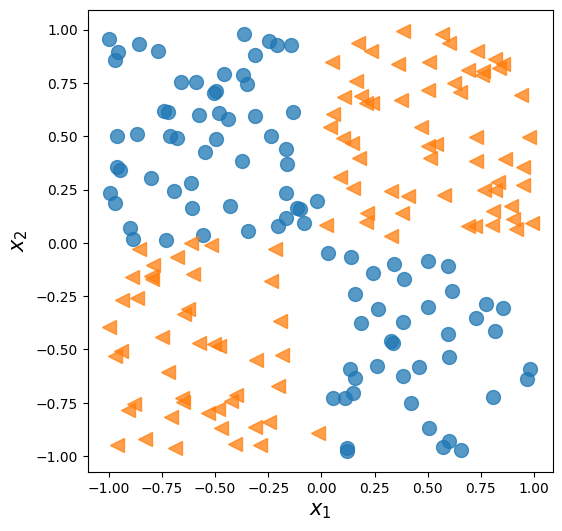

In [20]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


np.random.seed(1)
torch.manual_seed(1)
x = np.random.uniform(low=-1, high=1, size=(200, 2))
y = np.ones(len(x))
y[x[:, 0] * x[:, 1]<0] = 0

n_train = 100
x_train = torch.tensor(x[:n_train, :], dtype=torch.float32)
y_train = torch.tensor(y[:n_train], dtype=torch.float32)
x_valid = torch.tensor(x[n_train:, :], dtype=torch.float32)
y_valid = torch.tensor(y[n_train:], dtype=torch.float32)

fig = plt.figure(figsize=(6, 6))
plt.plot(x[y==0, 0], 
         x[y==0, 1], 'o', alpha=0.75, markersize=10)
plt.plot(x[y==1, 0], 
         x[y==1, 1], '<', alpha=0.75, markersize=10)
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$x_2$', size=15)

#plt.savefig('figures/13_02.png', dpi=300)
plt.show()

We now need to decide what architecture we should choose for this task and dataset. As a general rule of thumb, the more layers we have, and the more neurons we have in each layer, the larger the capacity of the model will be. Here, the *model capacity* can be thought of as a measure of how readily the model can approximate complex functions. While having more parameters means the network can fit more complex functions, larger models are usually harder to train (and prone to overfitting). In practice, it is always a good idea to start with a simple model as a baseline, for example, a single-layer NN like logistic regression.

In [21]:
model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

model

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)

After defining the model, we will initialize the cross-entropy loss function for binary classification and the SGD optimizer.

In [22]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

Next, we will create a data loader that uses a batch size of 2 for the train data.

In [23]:
from torch.utils.data import DataLoader, TensorDataset
 
    
train_ds = TensorDataset(x_train, y_train)
batch_size = 2
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

Now we will train the model for 200 epochs and record a history of training epochs.

**Result explanation**

This results in the following figure, with two separate panels for the losses and accuracies.

As you can see, a simple model with no hidden layer can only derive a linear decision boundary, which is unable to solve the XOR problem. As a consequence, we can observe that the loss terms for both the training and the validation datasets are very high, and the classification accuracy is very low.

In [24]:
torch.manual_seed(1)
num_epochs = 200
def train(model, num_epochs, train_dl, x_valid, y_valid):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    for epoch in range(num_epochs):
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item()
            is_correct = ((pred>=0.5).float() == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.mean()

        loss_hist_train[epoch] /= n_train/batch_size
        accuracy_hist_train[epoch] /= n_train/batch_size

        pred = model(x_valid)[:, 0]
        loss = loss_fn(pred, y_valid)
        loss_hist_valid[epoch] = loss.item()
        is_correct = ((pred>=0.5).float() == y_valid).float()
        accuracy_hist_valid[epoch] += is_correct.mean()
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

history = train(model, num_epochs, train_dl, x_valid, y_valid)

Text(0.5, 0, 'Epochs')

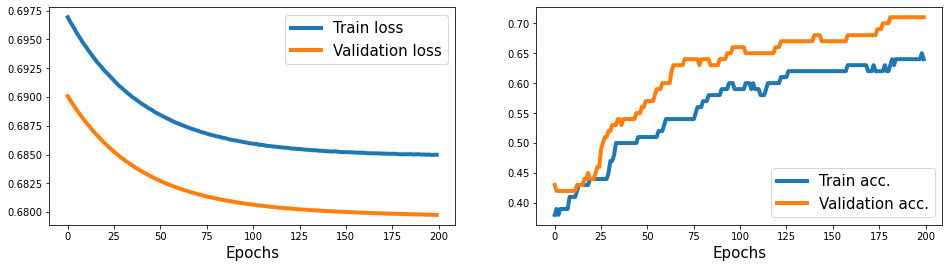

In [23]:
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 2, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

#plt.savefig('figures/13_03.png', dpi=300)

**Nonlinear decision boundary for better classification**

To derive a nonlinear decision boundary, we can add one or more hidden layers connected via nonlinear activation functions. The universal approximation theorem states that a feedforward NN with a single hidden layer and a relatively large number of hidden units can approximate arbitrary continuous functions relatively well. Thus, one approach for tackling the XOR problem more satisfactorily is to add a hidden layer and compare different numbers of hidden units until we observe satisfactory results on the validation dataset. Adding more hidden units would correspond to increasing the width of a layer.

Alternatively, we can also add more hidden layers, which will make the model deeper. The advantage of making a network deeper rather than wider is that fewer parameters are required to achieve a comparable model capacity.

However, a downside of deep (versus wide) models is that deep models are prone to vanishing and exploding gradients, which make them harder to train.

As an exercise, try adding one, two, three, and four hidden layers, each with four hidden units. In the following example, we will take a look at the results of a feedforward NN with two hidden layers.

**Result explanation**

Now, we can see that the model is able to derive a nonlinear decision boundary for this data, and the model reaches 100 percent accuracy on the training dataset. The validation dataset's accuracy is 95 percent, which indicates that the model is slightly overfitting.

In [25]:
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)
 
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)

model

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
  (5): Sigmoid()
)

Text(0.5, 0, 'Epochs')

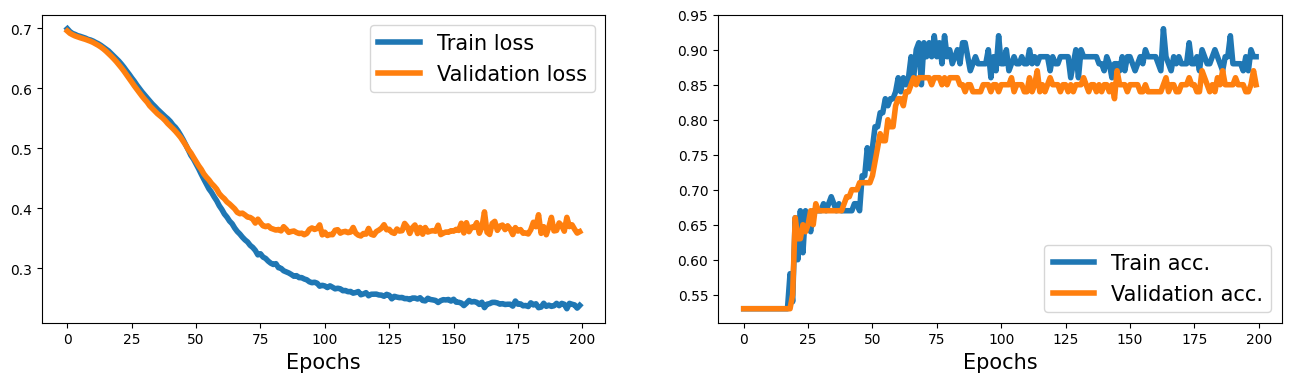

In [26]:
history = train(model, num_epochs, train_dl, x_valid, y_valid)

fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 2, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

#plt.savefig('figures/13_04.png', dpi=300)

### 13.5.4.Making model building more flexible with nn.Module
In the previous example, we used the PyTorch `Sequential` class to create a fully connected NN with multiple layers. This is a very common and convenient way of building models. However, it unfortunately doesn't allow us to create more complex models that have multiple input, output, or intermediate branches. That's where `nn.Module` comes in handy.

The alternative way to build complex models is by subclassing `nn.Module`. In this approach, we create a new class derived from `nn.Module` and define the method, 
- `__init__()`
	- We define the layers as attributes of the class so that they can be accessed via the `self` reference attribute.
- `forward()` 
	- We specify how these layers are to be used in the forward pass of the NN.
- `predict()`
	- To compute the decision boundary of our model.
	- It will return the predicted class (0 or 1) for a sample.

Notice that we put all layers in the `nn.ModuleList` object, which is just a list object composed of `nn.Module` items.

In [30]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        l1 = nn.Linear(2, 4)
        a1 = nn.ReLU()
        l2 = nn.Linear(4, 4)
        a2 = nn.ReLU()
        l3 = nn.Linear(4, 1)
        a3 = nn.Sigmoid()
        l = [l1, a1, l2, a2, l3, a3]
        self.module_list = nn.ModuleList(l)

    def forward(self, x):
        for f in self.module_list:
            x = f(x)
        return x
    
    def predict(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        pred = self.forward(x)[:, 0]
        return (pred>=0.5).float()
            

Once we define an instance of this new class, we can train it as we did previously.

In [32]:
model = MyModule()
print(model)

loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)
    
# torch.manual_seed(1)
history = train(model, num_epochs, train_dl, x_valid, y_valid)

MyModule(
  (module_list): ModuleList(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


Next, besides the train history, we will use the `mlxtend` library to visualize the validation data and the decision boundary. The following code will plot the training performance along with the decision region bias.

**Result explanation**

This results with three separate panels for the losses, accuracies, and the scatterplot of the validation examples, along with the decision boundary.

In [29]:
# !pip install mlxtend

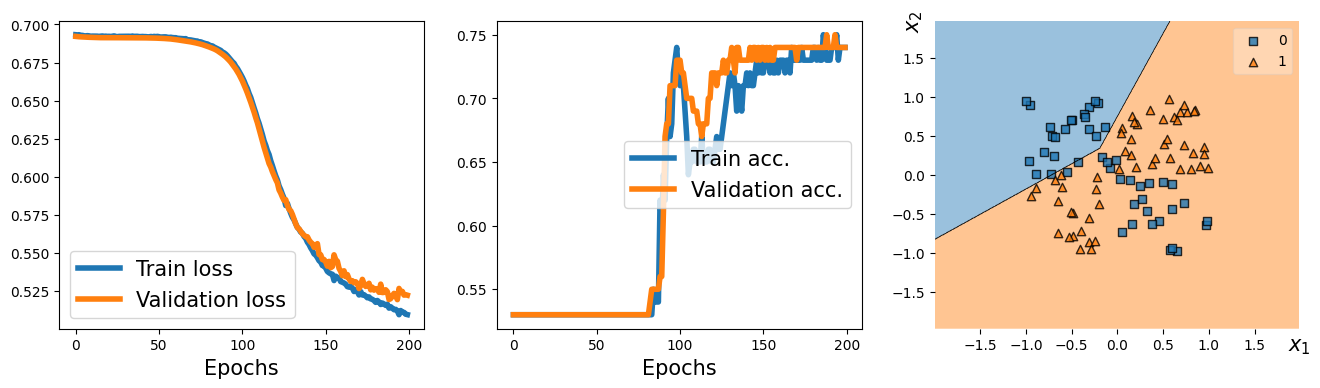

In [33]:
from mlxtend.plotting import plot_decision_regions


fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 3, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_valid.numpy(), 
                      y=y_valid.numpy().astype(np.int64),
                      clf=model)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)

#plt.savefig('figures/13_05.png', dpi=300)
plt.show()

### 13.5.5.Writing custom layers in PyTorch
In cases where we want to define a new layer that is not already supported by PyTorch, we can define a new class derived from the `nn.Module` class. This is especially useful when designing a new layer or customizing an existing layer.

To illustrate the concept of implementing custom layers, let's consider a simple example. Imagine we want to define a new linear layer that computes $w(x+\epsilon)+b$, where $\epsilon$ refers to a random variable as a noise variable. To implement this computation, we define a new class as a subclass of `nn.Module`. For this new class, `NoiseyLinear`, we define:
- `__init__()`  
	- In the constructor, we define the variables and other required tensors for our customized layer. We can create variables and initialize them in the constructor if the `input_size` is given to the constructor. Alternatively, we can delay the variable initialization (for instance, if we do not know the exact input shape upfront) and delegate it to another method for late variable creation.
	- `noise_stddev`, to specify the standard deviation for the distribution of $\epsilon$, which is sampled from a Gaussian distribution.
- `forward()` 
	- `training=False`, to distinguish whether the layer is used during training or only for prediction (this is sometimes also called inference) or evaluation. 


Note that the *random vector*, $\epsilon$, was to be generated and added to the input during training only and not used for inference or evaluation.

In [34]:
class NoisyLinear(nn.Module):
    def __init__(self, input_size, output_size, noise_stddev=0.1):
        super().__init__()
        w = torch.Tensor(input_size, output_size)
        self.w = nn.Parameter(w)  # nn.Parameter is a Tensor that's a module parameter.
        nn.init.xavier_uniform_(self.w)
        b = torch.Tensor(output_size).fill_(0)
        self.b = nn.Parameter(b)
        self.noise_stddev = noise_stddev

    def forward(self, x, training=False):
        if training:
            noise = torch.normal(0.0, self.noise_stddev, x.shape)
            x_new = torch.add(x, noise)
        else:
            x_new = x
        return torch.add(torch.mm(x_new, self.w), self.b)   

Before we go a step further and use our custom `NoisyLinear` layer in a model, let's test it in the context of a simple example.
1. In the following code, we will define a new instance of this layer, and execute it on an input tensor. Then, we will call the layer three times on the same input tensor:

In [35]:
torch.manual_seed(1)

noisy_layer = NoisyLinear(4, 2)
 
x = torch.zeros((1, 4))
print(noisy_layer(x, training=True))

print(noisy_layer(x, training=True))
 
print(noisy_layer(x, training=False))
 

tensor([[ 0.1154, -0.0598]], grad_fn=<AddBackward0>)
tensor([[ 0.0432, -0.0375]], grad_fn=<AddBackward0>)
tensor([[0., 0.]], grad_fn=<AddBackward0>)


2. Now, let’s create a new model similar to the previous one for solving the XOR classification task, `MyNoisyModule`. As before, we will use the `nn.Module` class for model building, but this time, we will use our `NoisyLinear` layer as the first hidden layer of the multilayer perceptron. The code is as follows:

In [36]:
class MyNoisyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = NoisyLinear(2, 4, 0.07)
        self.a1 = nn.ReLU()
        self.l2 = nn.Linear(4, 4)
        self.a2 = nn.ReLU()
        self.l3 = nn.Linear(4, 1)
        self.a3 = nn.Sigmoid()
        
    def forward(self, x, training=False):
        x = self.l1(x, training)
        x = self.a1(x)
        x = self.l2(x)
        x = self.a2(x)
        x = self.l3(x)
        x = self.a3(x)
        return x
    
    def predict(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        pred = self.forward(x)[:, 0]
        return (pred>=0.5).float()

torch.manual_seed(1)
model = MyNoisyModule()
model

MyNoisyModule(
  (l1): NoisyLinear()
  (a1): ReLU()
  (l2): Linear(in_features=4, out_features=4, bias=True)
  (a2): ReLU()
  (l3): Linear(in_features=4, out_features=1, bias=True)
  (a3): Sigmoid()
)

3. Similarly, we will train the model as we did previously. At this time, to compute the prediction on the training batch, we use `pred = model(x_batch, True)[:, 0]` instead of `pred = model(x_batch)[:, 0]`:

In [37]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)
    
torch.manual_seed(1)

loss_hist_train = [0] * num_epochs
accuracy_hist_train = [0] * num_epochs
loss_hist_valid = [0] * num_epochs
accuracy_hist_valid = [0] * num_epochs
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch, True)[:, 0]
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist_train[epoch] += loss.item()
        is_correct = ((pred>=0.5).float() == y_batch).float()
        accuracy_hist_train[epoch] += is_correct.mean()

    loss_hist_train[epoch] /= n_train/batch_size
    accuracy_hist_train[epoch] /= n_train/batch_size

    pred = model(x_valid)[:, 0]
    loss = loss_fn(pred, y_valid)
    loss_hist_valid[epoch] = loss.item()
    is_correct = ((pred>=0.5).float() == y_valid).float()
    accuracy_hist_valid[epoch] += is_correct.mean()

4. After the model is trained, we can plot the losses, accuracies, and the decision boundary:

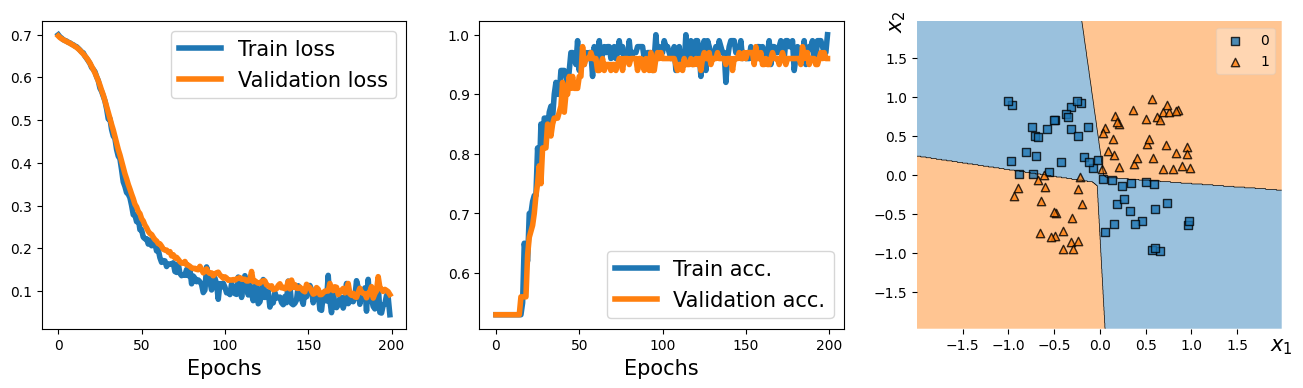

In [38]:
from mlxtend.plotting import plot_decision_regions


fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(loss_hist_train, lw=4)
plt.plot(loss_hist_valid, lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 3, 2)
plt.plot(accuracy_hist_train, lw=4)
plt.plot(accuracy_hist_valid, lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_valid.numpy(), 
                      y=y_valid.numpy().astype(np.int64),
                      clf=model)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)

#plt.savefig('figures/13_06.png', dpi=300)
plt.show()

---

Readers may ignore the next cell.

In [36]:
! python ../.convert_notebook_to_script.py --input ch13_part1.ipynb --output ch13_part1.py

[NbConvertApp] Converting notebook ch13_part1.ipynb to script
[NbConvertApp] Writing 14084 bytes to ch13_part1.py
